In [2]:
# Create combined dataset from NLP-predicted and manually classified data

import pandas as pd

# Load NLP predictions and manually classified data
pdf = pd.read_csv("vsrs_1240_predicted.csv")
cdf = pd.read_csv("vsrs_400_classified.csv")

# Create combined dataset for LS1 predictions
ls1 = pdf.copy()
ls1["Classification"] = ls1["LS1 Classification"]
ls1 = ls1.drop(columns=["LS1 Classification", "LS2 Classification"])
ls1 = pd.concat([ls1, cdf], ignore_index=True)
ls1.to_csv("vsrs_1640_LS1.csv", index=False)

# Create combined dataset for LS2 predictions
ls2 = pdf.copy()
ls2["Classification"] = ls2["LS2 Classification"]
ls2 = ls2.drop(columns=["LS1 Classification", "LS2 Classification"])
ls2 = pd.concat([ls2, cdf], ignore_index=True)
ls2.to_csv("vsrs_1640_LS2.csv", index=False)

In [4]:
import pandas as pd

# Load combined dataset for LS1 and LS2
ls1_df = pd.read_csv("vsrs_1640_LS1.csv")
ls2_df = pd.read_csv("vsrs_1640_LS2.csv")

# Determine number of jobs in each category for LS1 and LS2
for model, df in [("ls1", ls1_df), ("ls2", ls2_df)]:
    for colour in ["green", "amber", "blue"]:
        globals()[f"{colour}_{model}"] = (df["Classification"] == colour).sum()
        print(f"{model.upper()} {colour.title()}:",globals()[f"{colour}_{model}"])
    print("-" * 40)

# Quarters corresponding to the selected dataset snapshots
quarters = (
    '2022_10_2', '2023_1_1', '2023_4_2', '2023_7_5',
    '2023_10_1', '2024_1_7', '2024_4_7', '2024_7_7',
    '2024_10_6', '2025_1_5', '2025_4_6', '2025_7_6'
)

# Determine number of jobs in each category for LS1 and LS2 for each quarter
for model, df in [("ls1", ls1_df), ("ls2", ls2_df)]:
    for quarter in quarters:
        quarter_df = df[df["quarter"] == quarter]
        for colour in ["green", "amber", "blue"]:
            variable_name = f"{colour}_{quarter}_{model}"
            globals()[variable_name] = (quarter_df["Classification"] == colour).sum()
            print(f"{variable_name}:", globals()[variable_name])
    print("-" * 40)

LS1 Green: 672
LS1 Amber: 384
LS1 Blue: 184
----------------------------------------
LS2 Green: 675
LS2 Amber: 384
LS2 Blue: 181
----------------------------------------
green_2022_10_2_ls1: 75
amber_2022_10_2_ls1: 19
blue_2022_10_2_ls1: 3
green_2023_1_1_ls1: 100
amber_2023_1_1_ls1: 31
blue_2023_1_1_ls1: 17
green_2023_4_2_ls1: 78
amber_2023_4_2_ls1: 60
blue_2023_4_2_ls1: 18
green_2023_7_5_ls1: 36
amber_2023_7_5_ls1: 8
blue_2023_7_5_ls1: 3
green_2023_10_1_ls1: 75
amber_2023_10_1_ls1: 77
blue_2023_10_1_ls1: 54
green_2024_1_7_ls1: 68
amber_2024_1_7_ls1: 94
blue_2024_1_7_ls1: 26
green_2024_4_7_ls1: 46
amber_2024_4_7_ls1: 38
blue_2024_4_7_ls1: 15
green_2024_7_7_ls1: 18
amber_2024_7_7_ls1: 3
blue_2024_7_7_ls1: 1
green_2024_10_6_ls1: 50
amber_2024_10_6_ls1: 32
blue_2024_10_6_ls1: 25
green_2025_1_5_ls1: 66
amber_2025_1_5_ls1: 10
blue_2025_1_5_ls1: 10
green_2025_4_6_ls1: 33
amber_2025_4_6_ls1: 11
blue_2025_4_6_ls1: 12
green_2025_7_6_ls1: 27
amber_2025_7_6_ls1: 1
blue_2025_7_6_ls1: 0
-----------

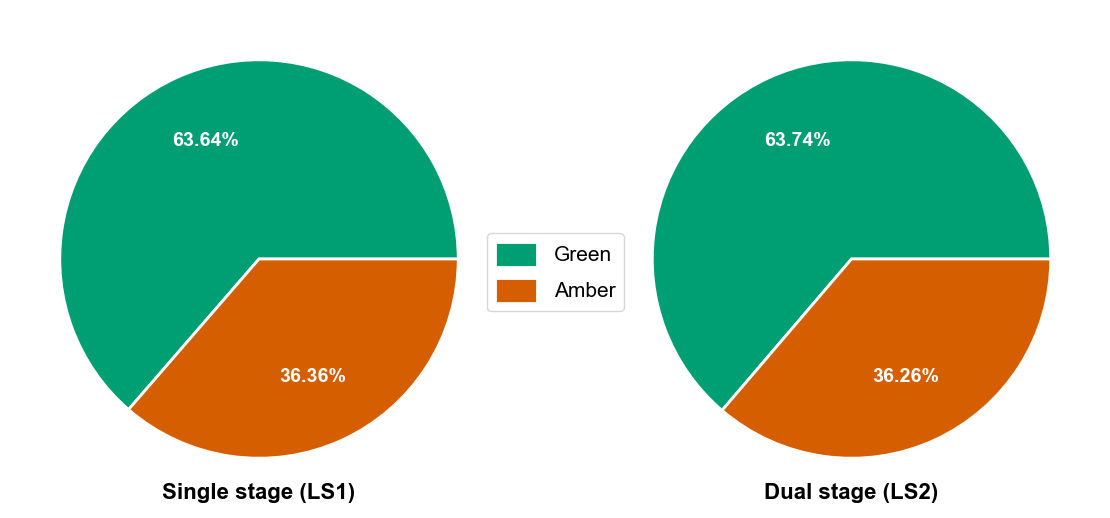

In [5]:
# Create VSRS pie charts

import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Arial"

# Load classification datasets
ls1_df = pd.read_csv("vsrs_1640_LS1.csv")
ls2_df = pd.read_csv("vsrs_1640_LS2.csv")

labels = ['Green', 'Amber']

# Count jobs in each classification category
values1 = [
    (ls1_df["Classification"] == "green").sum(),
    (ls1_df["Classification"] == "amber").sum()
]
values2 = [
    (ls2_df["Classification"] == "green").sum(),
    (ls2_df["Classification"] == "amber").sum(),
]

colors = ['#009E73', '#D55E00']

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Pie chart LS1
axes[0].pie(values1, colors=colors, autopct='%1.2f%%', pctdistance=0.65,
            textprops={'fontsize': 14, 'fontweight': 'bold', 'color': 'white'},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].text(0.5, 0.05, "Single stage (LS1)", transform=axes[0].transAxes,
             ha='center', va='top', fontsize=16, fontweight='bold')

# Pie chart LS2
axes[1].pie(values2, colors=colors, autopct='%1.2f%%', pctdistance=0.65,
            textprops={'fontsize': 14, 'fontweight': 'bold', 'color': 'white'},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].text(0.5, 0.05, "Dual stage (LS2)", transform=axes[1].transAxes,
             ha='center', va='top', fontsize=16, fontweight='bold')

# Shared legend
fig.legend(
    labels,
    loc='upper center',
    ncol=1,
    fontsize=15,
    handlelength=2,
    handleheight=1.5,
    frameon=True,
    bbox_to_anchor=(0.5, 0.5)
)

plt.tight_layout(rect=[0, 0, 1, 0.88])

plt.savefig('fdf_nlp_pie.svg', format='svg', bbox_inches='tight')

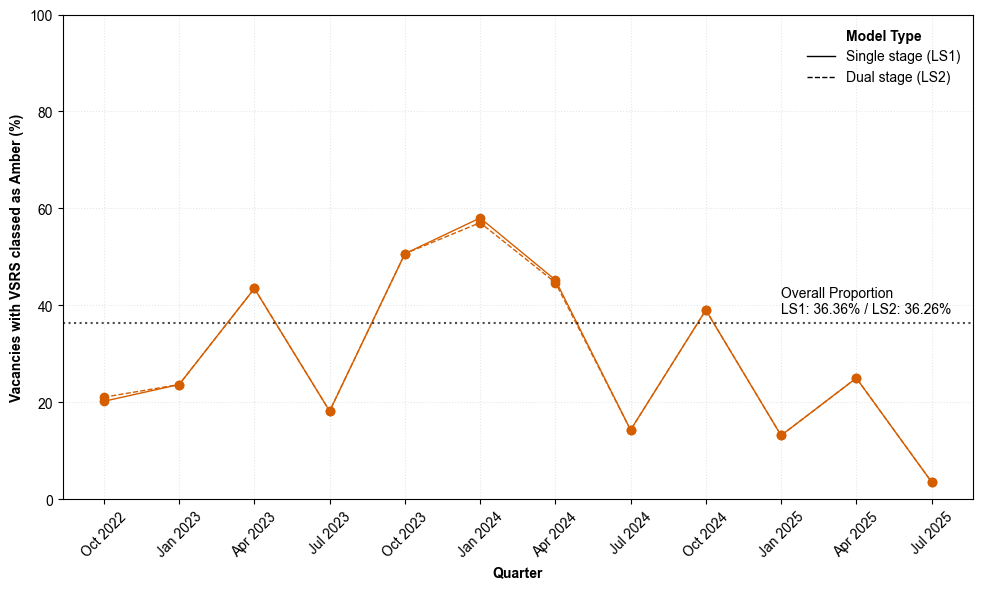

In [32]:
# Plot quarterly VSRS trends

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Quarters corresponding to the selected dataset snapshots
quarters = (
    '2022_10_2', '2023_1_1', '2023_4_2', '2023_7_5',
    '2023_10_1', '2024_1_7', '2024_4_7', '2024_7_7',
    '2024_10_6', '2025_1_5', '2025_4_6', '2025_7_6'
)

labels = [
    "Oct 2022", "Jan 2023", "Apr 2023", "Jul 2023",
    "Oct 2023", "Jan 2024", "Apr 2024", "Jul 2024",
    "Oct 2024", "Jan 2025", "Apr 2025", "Jul 2025"
]

# Colour for each classification
colours = {
    "green": "#009E73",
    "amber": "#D55E00",
}

fig, ax = plt.subplots(figsize=(10, 6))

# Plot the dataset
for model in ["ls1", "ls2"]:
    amber = [
        globals()[f"amber_{quarter}_{model}"]
        for quarter in quarters
    ]
    green = [
        globals()[f"green_{quarter}_{model}"]
        for quarter in quarters
    ]
    proportion = [ #%
        amber / (amber + green) * 100
        for amber, green in zip(amber, green)
    ]

    # LS1 = solid, LS2 = dashed
    linestyle = "-" if model == "ls1" else "--"
    ax.plot(
        labels,
        proportion,
        color=colours["amber"],
        linestyle=linestyle,
        marker="o",
        linewidth=1,
        markersize=6
        )

# Overall Line
prop_ls1 = amber_ls1 / (amber_ls1 + green_ls1) * 100
prop_ls2 = amber_ls2 / (amber_ls2 + green_ls2) * 100
ax.axhline(
    (prop_ls1 + prop_ls2) / 2,
    color="black",
    linestyle=":",
    linewidth=1.5,
    alpha=0.7
)
ax.text(
    len(labels) - 3,
    prop_ls1 + 2,
    f"Overall Proportion\nLS1: {prop_ls1:.2f}% / LS2: {prop_ls2:.2f}%",
    ha="left",
)

# Labels
ax.set_xlabel(
    "Quarter",
    fontweight="bold"
)
ax.set_ylabel(
    "Vacancies with VSRS classed as Amber (%)",
    fontweight="bold"
)

# Limit y-axis
ax.set_ylim(0, 100)

# Formatting
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45)

ax.grid(
    True,
    alpha=0.3,
    linestyle=":"
)

# Model legend
model_legend = [
    Line2D(
        [0], [0],
        color="black",
        linestyle="-",
        linewidth=1,
        label="Single stage (LS1)"
    ),
    Line2D(
        [0], [0],
        color="black",
        linestyle="--",
        linewidth=1,
        label="Dual stage (LS2)"
    )
]

# Add legend
legend1 = ax.legend( # Add model legend
    handles=model_legend,
    loc="lower right",
    bbox_to_anchor=(1, 0.83),
    title="Model Type",
    title_fontproperties={"weight": "bold"},
    frameon=False,
    ncol=1
)

fig.tight_layout()

plt.savefig(
    "fdf_nlp_line.svg",
    format="svg",
    bbox_inches="tight"
)